# Phase 4: Feature Engineering
**Project:** Customer Churn Intelligence  
**Input:** `../data/processed/telco_churn_clean.csv`  
**Output:** `../data/processed/telco_churn_features.csv`  

---
### Objectives & Engineering Strategy
In this phase, we transform raw demographic, service, and contractual attributes into domain-informed behavioral indicators.
1. **Domain-Driven Aggregations:** Grouping services into functional clusters (Security/Support vs. Entertainment/Streaming).
2. **Account Maturity & Tenure Segmentation:** Cohorting customer tenure into distinct loyalty phases.
3. **Billing Dynamics:** Calculating historical revenue averages, price trajectory differences, and charge tiers while properly resolving the `tenure == 0` edge condition.
4. **Separation of Raw vs. Engineered Features:** Maintaining transparent lineage between raw inputs and synthesized representations.
5. **No Premature Oversampling:** SMOTE and feature scalers remain strictly deferred until the Phase 5 ML pipeline.


## Step 0 — Setup & Ingest Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

clean_path = "../data/processed/telco_churn_clean.csv"
df = pd.read_csv(clean_path)
print(f"Loaded clean dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)


Loaded clean dataset: 7043 rows, 20 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


---
## Feature 1 — Tenure Groups (`tenure_group`)

### Business Rationale:
In Phase 3 EDA, we observed steep, non-linear differences in churn across lifecycle stages:
- **0–12 months (New):** ~47.7% churn (High vulnerability onboarding stage)
- **13–24 months (Early):** ~28.7% churn (Stabilization stage)
- **25–48 months (Established):** ~19.3% churn (Maturing loyalty)
- **49–72 months (Loyal):** ~9.5% churn (Entrenched brand loyalty)

Binning continuous tenure into ordinal lifecycle stages allows tree-based models and linear classifiers to capture non-linear step-function hazards without excessive polynomial terms.


In [2]:
# Define tenure bins and labels
bins = [-1, 12, 24, 48, 72]
labels = ['New', 'Early', 'Established', 'Loyal']

df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels)
print("Distribution of tenure_group:")
print(df['tenure_group'].value_counts(sort=False))

# Verify churn rate by tenure group
tenure_churn = df.groupby('tenure_group')['Churn'].agg(['count', 'mean']).reset_index()
tenure_churn['Churn_Rate_%'] = (tenure_churn['mean'] * 100).round(2)
tenure_churn


Distribution of tenure_group:
tenure_group
New            2186
Early          1024
Established    1594
Loyal          2239
Name: count, dtype: int64


,tenure_group,count,mean,Churn_Rate_%
0,New,2186,0.474382,47.44
1,Early,1024,0.287109,28.71
2,Established,1594,0.203890,20.39
3,Loyal,2239,0.095132,9.51


---
## Feature 2 — Total Active Services Count (`service_count`)

### Business Rationale:
Customers with higher product adoption have deeper switching barriers. However, we must be precise: **"No internet service" and "No phone service" must NOT be counted as active services**.

We evaluate 8 optional / modular service lines:
1. `PhoneService` (`Yes` = 1)
2. `MultipleLines` (`Yes` = 1)
3. `OnlineSecurity` (`Yes` = 1)
4. `OnlineBackup` (`Yes` = 1)
5. `DeviceProtection` (`Yes` = 1)
6. `TechSupport` (`Yes` = 1)
7. `StreamingTV` (`Yes` = 1)
8. `StreamingMovies` (`Yes` = 1)


In [3]:
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Calculate active services by summing instances where status == 'Yes'
df['service_count'] = 0
for col in service_cols:
    df['service_count'] += (df[col] == 'Yes').astype(int)

print("Distribution of active service count (0 to 8):")
print(df['service_count'].value_counts().sort_index())

# Churn rate by total service count
service_churn = df.groupby('service_count')['Churn'].agg(['count', 'mean']).reset_index()
service_churn['Churn_Rate_%'] = (service_churn['mean'] * 100).round(2)
service_churn


Distribution of active service count (0 to 8):
service_count
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64


,service_count,count,mean,Churn_Rate_%
0,0,80,0.437500,43.75
1,1,1701,0.211052,21.11
2,2,1188,0.328283,32.83
3,3,965,0.364767,36.48
4,4,922,0.313449,31.34
5,5,908,0.255507,25.55
6,6,676,0.224852,22.49
7,7,395,0.124051,12.41
8,8,208,0.052885,5.29


---
## Feature 3 — Average Monthly Revenue & Price Trajectory

### Business Rationale:
We compute historical monthly revenue:
$$\text{avg\_monthly\_revenue} = \frac{\text{TotalCharges}}{\text{tenure}}$$

#### Handling the Edge Case: `tenure == 0`
For brand-new signups (`tenure == 0`), division by zero results in `inf` or `NaN`.  
Because new customers have not yet paid previous invoices, their anticipated historical monthly revenue rate equals their first-month contracted fee: **`MonthlyCharges`**.

#### Information Beyond `MonthlyCharges`:
Does `avg_monthly_revenue` provide unique information?  
Yes: By comparing `MonthlyCharges - avg_monthly_revenue`, we capture **`monthly_charge_diff`** (billing trajectory).  
- A positive difference indicates **recent rate hikes or add-on upgrades** relative to historical averages.  
- Unexpected price increases frequently trigger bill-shock churn!


In [4]:
# Compute average monthly revenue with explicit handling of tenure == 0
df['avg_monthly_revenue'] = np.where(
    df['tenure'] == 0,
    df['MonthlyCharges'],
    df['TotalCharges'] / df['tenure']
)

# Compute billing trajectory: current monthly charges minus average historical charges
df['monthly_charge_diff'] = (df['MonthlyCharges'] - df['avg_monthly_revenue']).round(2)

print("Summary of avg_monthly_revenue and monthly_charge_diff:")
display(df[['MonthlyCharges', 'avg_monthly_revenue', 'monthly_charge_diff']].describe().round(2))

# Verify tenure == 0 rows have clean, valid finite values
print("\nVerification of tenure == 0 rows:")
display(df[df['tenure'] == 0][['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_revenue', 'monthly_charge_diff']])


Summary of avg_monthly_revenue and monthly_charge_diff:


,MonthlyCharges,avg_monthly_revenue,monthly_charge_diff
count,7043.00,7043.00,7043.00
mean,64.76,64.76,-0.00
std,30.09,30.19,2.61
min,18.25,13.78,-18.90
25%,35.50,35.94,-1.16
50%,70.35,70.34,0.00
75%,89.85,90.17,1.14
max,118.75,121.40,19.13



Verification of tenure == 0 rows:


,tenure,MonthlyCharges,TotalCharges,avg_monthly_revenue,monthly_charge_diff
488,0,52.55,0.0,52.55,0.0
753,0,20.25,0.0,20.25,0.0
936,0,80.85,0.0,80.85,0.0
1082,0,25.75,0.0,25.75,0.0
1340,0,56.05,0.0,56.05,0.0
3331,0,19.85,0.0,19.85,0.0
3826,0,25.35,0.0,25.35,0.0
4380,0,20.00,0.0,20.00,0.0
5218,0,19.70,0.0,19.70,0.0
6670,0,73.35,0.0,73.35,0.0


---
## Feature 4 — Number of Streaming Services (`streaming_count`)

### Business Rationale:
Entertainment services (`StreamingTV` and `StreamingMovies`) represent lifestyle and content consumption.  
Range: 0, 1, or 2 active streaming subscriptions.


In [5]:
df['streaming_count'] = (
    (df['StreamingTV'] == 'Yes').astype(int) + 
    (df['StreamingMovies'] == 'Yes').astype(int)
)

print("Distribution of streaming_count:")
print(df['streaming_count'].value_counts().sort_index())

# Churn rate by streaming count
streaming_churn = df.groupby('streaming_count')['Churn'].agg(['count', 'mean']).reset_index()
streaming_churn['Churn_Rate_%'] = (streaming_churn['mean'] * 100).round(2)
streaming_churn


Distribution of streaming_count:
streaming_count
0    3544
1    1559
2    1940
Name: count, dtype: int64


,streaming_count,count,mean,Churn_Rate_%
0,0,3544,0.227991,22.80
1,1,1559,0.314304,31.43
2,2,1940,0.294330,29.43


---
## Feature 5 — Support & Security Services Count (`support_security_count`)

### Business Rationale:
In Phase 3 EDA, tech support and online security showed massive churn-reduction power (~15% vs ~41% churn).  
We aggregate the 4 "stickiness & utility" features into a single composite score:
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`

Range: 0 to 4 protection/support add-ons.


In [6]:
support_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['support_security_count'] = 0
for col in support_cols:
    df['support_security_count'] += (df[col] == 'Yes').astype(int)

print("Distribution of support_security_count (0 to 4):")
print(df['support_security_count'].value_counts().sort_index())

support_churn = df.groupby('support_security_count')['Churn'].agg(['count', 'mean']).reset_index()
support_churn['Churn_Rate_%'] = (support_churn['mean'] * 100).round(2)
support_churn


Distribution of support_security_count (0 to 4):
support_security_count
0    2793
1    1467
2    1372
3     941
4     470
Name: count, dtype: int64


,support_security_count,count,mean,Churn_Rate_%
0,0,2793,0.297530,29.75
1,1,1467,0.388548,38.85
2,2,1372,0.237609,23.76
3,3,941,0.124336,12.43
4,4,470,0.053191,5.32


---
## Feature 6 — Contract & Tenure Interaction (`contract_tenure_group`)

### Business Rationale:
A month-to-month contract in year 1 represents maximum churn hazard. A two-year contract for an established customer represents minimal risk.  
Combining contract structure and tenure cohort isolates critical micro-segments for risk scoring.


In [7]:
df['contract_tenure_group'] = df['Contract'] + '_' + df['tenure_group'].astype(str)

print("Sample combinations of contract_tenure_group:")
print(df['contract_tenure_group'].value_counts().head(6))

# Churn rate across contract-tenure interactions
ct_churn = df.groupby('contract_tenure_group')['Churn'].agg(['count', 'mean']).reset_index()
ct_churn['Churn_Rate_%'] = (ct_churn['mean'] * 100).round(2)
ct_churn = ct_churn.sort_values(by='Churn_Rate_%', ascending=False)
display(ct_churn)


Sample combinations of contract_tenure_group:
contract_tenure_group
Month-to-month_New            1994
Two year_Loyal                1263
Month-to-month_Established     802
Month-to-month_Early           737
One year_Loyal                 634
One year_Established           518
Name: count, dtype: int64


,contract_tenure_group,count,mean,Churn_Rate_%
3,Month-to-month_New,1994,0.513541,51.35
0,Month-to-month_Early,737,0.377205,37.72
1,Month-to-month_Established,802,0.329177,32.92
2,Month-to-month_Loyal,342,0.260234,26.02
6,One year_Loyal,634,0.129338,12.93
5,One year_Established,518,0.106178,10.62
7,One year_New,124,0.104839,10.48
4,One year_Early,197,0.081218,8.12
10,Two year_Loyal,1263,0.033254,3.33
9,Two year_Established,274,0.021898,2.19


---
## Feature 7 — Monthly Charge Tiers (`monthly_charges_tier`)

### Business Rationale:
Segmenting monthly spend into 3 strategic pricing tiers:
- **Low (< $35/month):** Basic voice/budget tier (characterized by low churn)
- **Medium ($35–$70/month):** Mid-range DSL or single-service broadband
- **High (> $70/month):** Premium fiber optic and multi-service bundles (peak churn concentration)


In [8]:
def categorize_charge(charge):
    if charge < 35.0:
        return 'Low'
    elif charge <= 70.0:
        return 'Medium'
    else:
        return 'High'

df['monthly_charges_tier'] = df['MonthlyCharges'].apply(categorize_charge)

print("Distribution of monthly_charges_tier:")
print(df['monthly_charges_tier'].value_counts())

tier_churn = df.groupby('monthly_charges_tier')['Churn'].agg(['count', 'mean']).reset_index()
tier_churn['Churn_Rate_%'] = (tier_churn['mean'] * 100).round(2)
tier_churn


Distribution of monthly_charges_tier:
monthly_charges_tier
High      3583
Low       1731
Medium    1729
Name: count, dtype: int64


,monthly_charges_tier,count,mean,Churn_Rate_%
0,High,3583,0.353614,35.36
1,Low,1731,0.108608,10.86
2,Medium,1729,0.239445,23.94


---
## Feature Architecture: Raw vs. Engineered Separation

To ensure transparency and interpretability in production, we categorize all attributes:

### 1. Raw Baseline Features:
- Demographics: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- Tenure: `tenure`
- Services: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
- Account Terms: `Contract`, `PaperlessBilling`, `PaymentMethod`
- Financials: `MonthlyCharges`, `TotalCharges`
- Target: `Churn`

### 2. Engineered Features:
- `tenure_group`: Lifecycle maturity phase (`New`, `Early`, `Established`, `Loyal`)
- `service_count`: Count of active paid subscriptions (0 to 8)
- `avg_monthly_revenue`: Historical average bill rate
- `monthly_charge_diff`: Drift/spike between current bill and historical rate
- `streaming_count`: Count of active streaming entertainment add-ons (0, 1, 2)
- `support_security_count`: Count of protective lock-in services (0 to 4)
- `contract_tenure_group`: High-dimensional risk interaction feature
- `monthly_charges_tier`: Stratified spending level (`Low`, `Medium`, `High`)


In [9]:
raw_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges', 'Churn'
]

engineered_features = [
    'tenure_group', 'service_count', 'avg_monthly_revenue',
    'monthly_charge_diff', 'streaming_count', 'support_security_count',
    'contract_tenure_group', 'monthly_charges_tier'
]

print(f"Total Raw Features: {len(raw_features)}")
print(f"Total Engineered Features: {len(engineered_features)}")
print(f"Total Dataset Columns: {len(df.columns)}")
assert len(df.columns) == len(raw_features) + len(engineered_features)


Total Raw Features: 20
Total Engineered Features: 8
Total Dataset Columns: 28


### Correlation of Numerical & Engineered Features with Churn

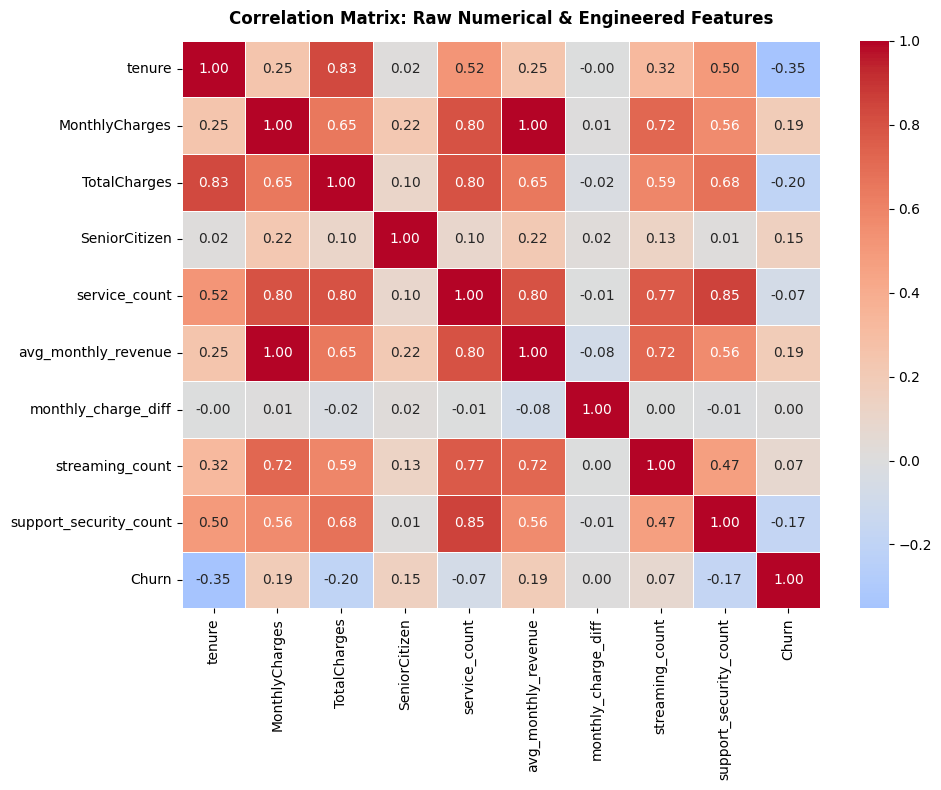

Direct correlation with Churn (sorted):
Churn                     1.000000
MonthlyCharges            0.193356
avg_monthly_revenue       0.192531
SeniorCitizen             0.150889
streaming_count           0.071162
monthly_charge_diff       0.002179
service_count            -0.067264
support_security_count   -0.173061
TotalCharges             -0.198324
tenure                   -0.352229
Name: Churn, dtype: float64


In [10]:
num_cols = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
    'service_count', 'avg_monthly_revenue', 'monthly_charge_diff',
    'streaming_count', 'support_security_count', 'Churn'
]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix: Raw Numerical & Engineered Features", fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("Direct correlation with Churn (sorted):")
print(corr['Churn'].sort_values(ascending=False))


---
## Phase 4 Output — Save Feature-Engineered Dataset
We export the model-ready dataset to `../data/processed/telco_churn_features.csv`.

*Reminder:* We intentionally **do not** perform SMOTE, standard scaling, or train/test splitting here. Those operations belong strictly within the isolated training folds of Phase 5 cross-validation to prevent data leakage.


In [11]:
output_path = "../data/processed/telco_churn_features.csv"
df.to_csv(output_path, index=False)
print(f"Model-ready features dataset saved successfully to: {output_path}")
print(f"Shape: {df.shape}")
df.info()


Model-ready features dataset saved successfully to: ../data/processed/telco_churn_features.csv
Shape: (7043, 28)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   gender                  7043 non-null   str     
 1   SeniorCitizen           7043 non-null   int64   
 2   Partner                 7043 non-null   str     
 3   Dependents              7043 non-null   str     
 4   tenure                  7043 non-null   int64   
 5   PhoneService            7043 non-null   str     
 6   MultipleLines           7043 non-null   str     
 7   InternetService         7043 non-null   str     
 8   OnlineSecurity          7043 non-null   str     
 9   OnlineBackup            7043 non-null   str     
 10  DeviceProtection        7043 non-null   str     
 11  TechSupport             7043 non-null   str     
 12  StreamingTV             7043 n